## ACLED — Armed Conflict Location & Event Data
ACLED records political violence and conflict events at the country-day level, capturing fatalities, event counts, and the nature of conflict activity.We expect countries with higher fatality counts and more frequent conflict events to be more likely to meet the CERF allocation-eligibility criteria, as intense conflict is a primary driver of internal displacement. The type of conflict also matters: civilian-targeted violence and heavy warfare are expected to be stronger predictors of displacement than social unrest or political violence.

### Part 1: Univariate Analysis
This section describes the distribution and coverage of ACLED variables independently of the target variable. The goal is to understand the data quality, detect outliers, and identify patterns in conflict activity across countries and time.

In [2]:
import os
import pandas as pd
import numpy as np

df = pd.read_csv('../data_clean/final_data.csv')
print(f"Data loaded successfully: {df.shape}")

Data loaded successfully: (17424, 100)


In [3]:
# ACLED variables
acled_cols = ['events', 'fatalities', 'acled_civilian_targeted', 'acled_heavy_warfare',
              'acled_social_unrest', 'acled_territorial_shift', 'acled_strategic_or_other',
              'acled_political_violence']

df[acled_cols].describe().round(2)

,events,fatalities,acled_civilian_targeted,acled_heavy_warfare,acled_social_unrest,acled_territorial_shift,acled_strategic_or_other,acled_political_violence
count,17424.00,17424.00,17424.00,17424.00,17424.0,17424.00,17424.00,17424.00
mean,148.09,90.34,0.61,0.37,0.8,0.06,0.53,0.61
std,415.92,487.66,0.49,0.48,0.4,0.24,0.50,0.49
min,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
25%,3.00,0.00,0.00,0.00,1.0,0.00,0.00,0.00
50%,21.00,0.00,1.00,0.00,1.0,0.00,1.00,1.00
75%,105.00,11.00,1.00,1.00,1.0,0.00,1.00,1.00
max,8115.00,27639.00,1.00,1.00,1.0,1.00,1.00,1.00


In [4]:
# Descriptive statistics for ACLED variables
acled_cols = ['events', 'fatalities']

df[acled_cols].describe().round(2)

,events,fatalities
count,17424.00,17424.00
mean,148.09,90.34
std,415.92,487.66
min,0.00,0.00
25%,3.00,0.00
50%,21.00,0.00
75%,105.00,11.00
max,8115.00,27639.00


In [5]:
# Missing values
print("Missing values:")
print(df[acled_cols].isnull().sum())
print(f"\nMissing percentage:")
print((df[acled_cols].isnull().sum() / len(df) * 100).round(2))

Missing values:
events        0
fatalities    0
dtype: int64

Missing percentage:
events        0.0
fatalities    0.0
dtype: float64


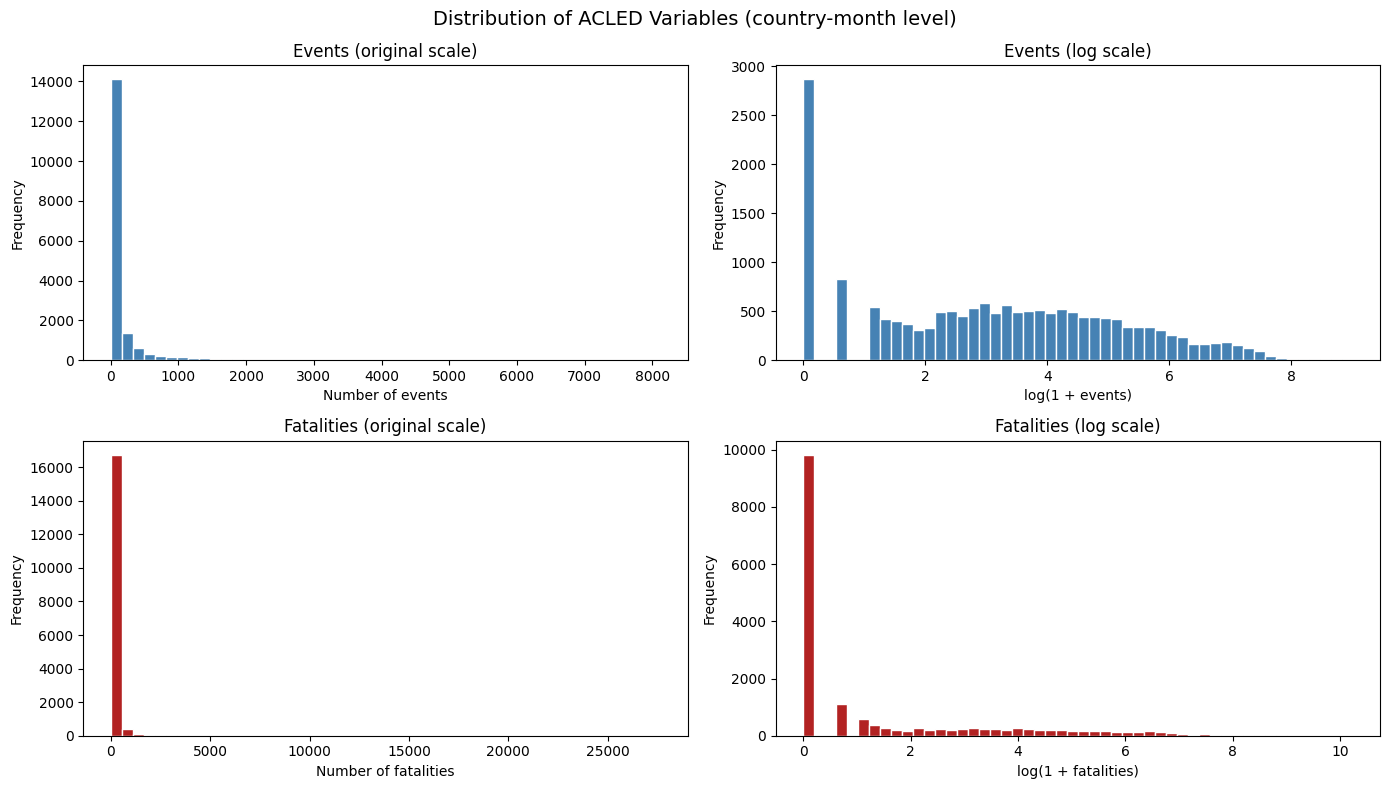

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Distribution of ACLED Variables (country-month level)', fontsize=14)

# Events - original
axes[0, 0].hist(df['events'], bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Events (original scale)')
axes[0, 0].set_xlabel('Number of events')
axes[0, 0].set_ylabel('Frequency')

# Events - log
axes[0, 1].hist(np.log1p(df['events']), bins=50, color='steelblue', edgecolor='white')
axes[0, 1].set_title('Events (log scale)')
axes[0, 1].set_xlabel('log(1 + events)')
axes[0, 1].set_ylabel('Frequency')

# Fatalities - original
axes[1, 0].hist(df['fatalities'], bins=50, color='firebrick', edgecolor='white')
axes[1, 0].set_title('Fatalities (original scale)')
axes[1, 0].set_xlabel('Number of fatalities')
axes[1, 0].set_ylabel('Frequency')

# Fatalities - log
axes[1, 1].hist(np.log1p(df['fatalities']), bins=50, color='firebrick', edgecolor='white')
axes[1, 1].set_title('Fatalities (log scale)')
axes[1, 1].set_xlabel('log(1 + fatalities)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Both variables show a strong right-skewed distribution at the country-month level. For `events`, most country-months record fewer than 500 events, with a few extreme cases reaching over 8,000. For `fatalities`, the skew is even more pronounced, over half of all country-months report zero fatalities, meaning that conflict-related deaths are concentrated in a small number of countries and time periods. Even after applying the log(1+x) transformation, the spike at zero remains dominant for fatalities, confirming that conflict is a rare and concentrated phenomenon in this dataset. This is consistent with the low share of allocation-eligible observations (3.9%) in the target variable.

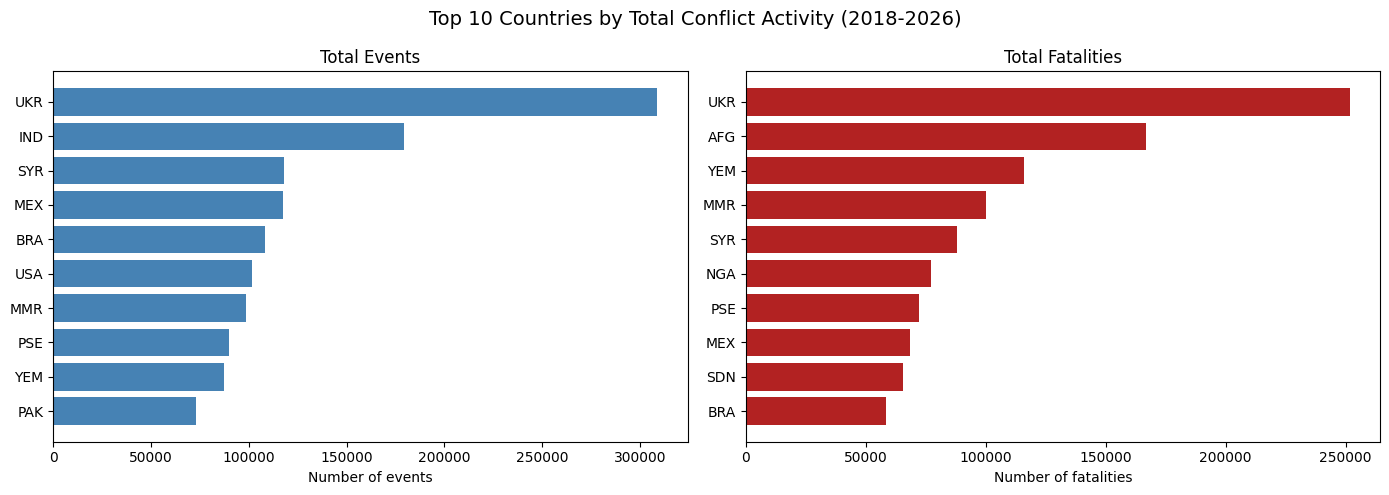

In [8]:
# Top 10 countries by total events and fatalities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Top 10 Countries by Total Conflict Activity (2018-2026)', fontsize=14)

# Top 10 by events
top_events = df.groupby('iso3')['events'].sum().nlargest(10)
axes[0].barh(top_events.index[::-1], top_events.values[::-1], color='steelblue')
axes[0].set_title('Total Events')
axes[0].set_xlabel('Number of events')

# Top 10 by fatalities
top_fatalities = df.groupby('iso3')['fatalities'].sum().nlargest(10)
axes[1].barh(top_fatalities.index[::-1], top_fatalities.values[::-1], color='firebrick')
axes[1].set_title('Total Fatalities')
axes[1].set_xlabel('Number of fatalities')

plt.tight_layout()
plt.show()

The charts display the top 10 countries by total accumulated events and fatalities over the study period. Ukraine ranks first in both lists, which is expected given the scale of conflict following the Russian invasion in 2022. While several countries appear in both rankings, the order differs, suggesting that conflict frequency and lethality do not always go hand in hand. Some countries record many events with relatively few deaths, while others concentrate high fatality counts in fewer but more deadly incidents. This confirms that both variables capture different dimensions of conflict.

In [10]:
# Extract year from month
df['year'] = pd.to_datetime(df['month']).dt.year

# Average monthly events and fatalities by year
yearly_avg = df.groupby('year')[['events', 'fatalities']].mean().round(2)
yearly_avg.columns = ['Avg Monthly Events', 'Avg Monthly Fatalities']
yearly_avg

,Avg Monthly Events,Avg Monthly Fatalities
year,,
2018,100.28,84.63
2019,109.05,72.69
2020,126.44,65.91
2021,137.75,75.79
2022,153.59,81.48
2023,166.24,95.01
2024,184.93,118.40
2025,192.82,114.80
2026,202.70,146.46


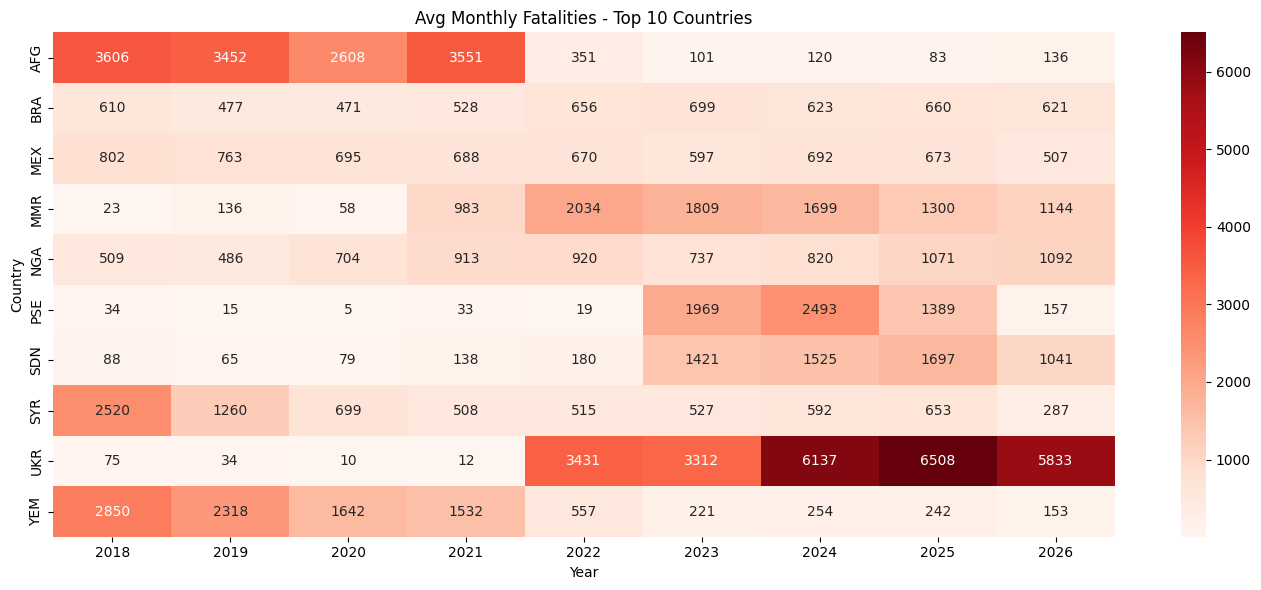

In [13]:
import seaborn as sns

# Top 10 countries by total fatalities
top10_fatalities = df.groupby('iso3')['fatalities'].sum().nlargest(10).index

yearly_country = df[df['iso3'].isin(top10_fatalities)].groupby(['year', 'iso3'])['fatalities'].mean().round(2)

pivot_fatalities = yearly_country.unstack(level=0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_fatalities, cmap='Reds', fmt='.0f', annot=True, ax=ax)
ax.set_title('Avg Monthly Fatalities - Top 10 Countries')
ax.set_xlabel('Year')
ax.set_ylabel('Country')

plt.tight_layout()
plt.show()

The heatmap displays the average monthly fatalities for the 10 countries with the highest cumulative death over the study period (2018-2026). These countries are concentrated in conflict-prone regions: the Middle East (Syria, Yemen, Palestine), Sub-Saharan Africa (Nigeria, Sudan), Southeast Asia (Myanmar), Eastern Europe (Ukraine), and South Asia (Afghanistan). Several patterns stand out. Afghanistan recorded the highest monthly averages between 2018 and 2021 (above 3,000 deaths per month), dropping sharply after the Taliban takeover in August 2021. Ukraine shows the opposite trend , nearly no fatalities before 2022, then surging to over 6,000 monthly deaths by 2024 following the Russian invasion. Palestine (PSE) follows a similar pattern, remaining low until 2023 when the Gaza conflict began. Mexico is a notable case, it consistently appears in the top 10 despite not being associated with conventional armed conflict. Its presence reflects ongoing cartel-related violence, which ACLED classifies as political violence, resulting in hundreds of fatalities every month throughout the entire period.

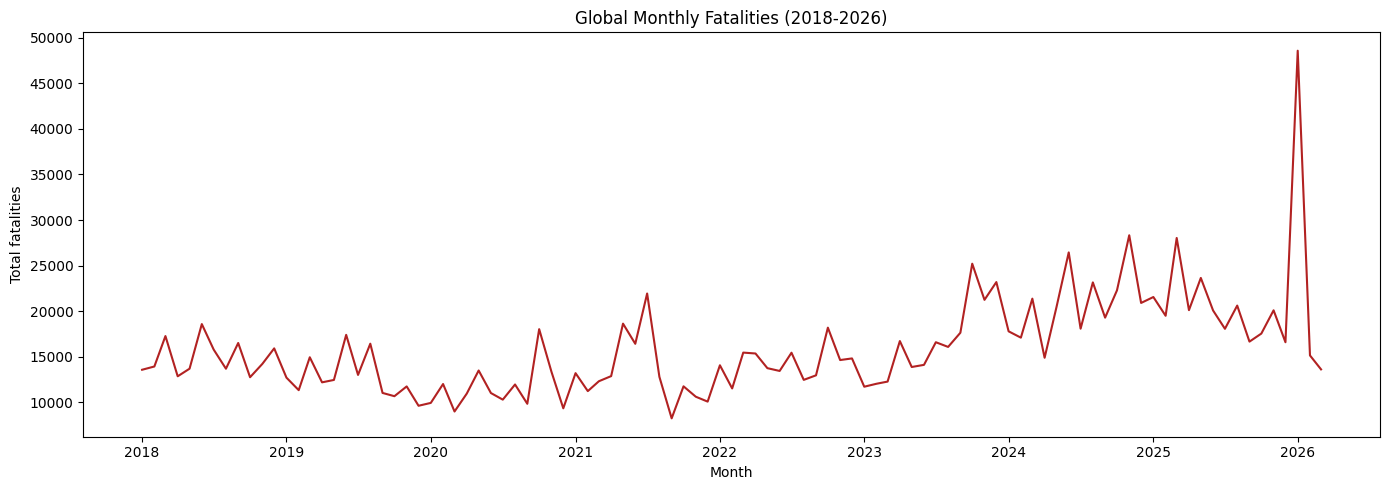

In [14]:
# Global monthly fatalities over time
global_monthly = df.groupby('month')['fatalities'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pd.to_datetime(global_monthly['month']), global_monthly['fatalities'], 
        color='firebrick', linewidth=1.5)
ax.set_title('Global Monthly Fatalities (2018-2026)')
ax.set_xlabel('Month')
ax.set_ylabel('Total fatalities')
plt.tight_layout()
plt.show()

In [15]:
# Identify which country drives the 2026 spike
spike_2026 = df[pd.to_datetime(df['month']).dt.year == 2026].groupby('iso3')['fatalities'].sum().nlargest(10)
print(spike_2026)

iso3
IRN    28908.0
UKR    17498.0
MMR     3432.0
NGA     3277.0
SDN     3124.0
SOM     2033.0
BRA     1864.0
ETH     1548.0
MEX     1521.0
PAK     1454.0
Name: fatalities, dtype: float64


The global monthly fatalities series shows a relatively stable baseline between 2018 and 2022, ranging between 10,000 and 20,000 deaths per month. From 2023 onward, a clear upward trend emerges, driven by the simultaneous escalation of multiple active conflicts ,particularly Ukraine, Sudan, and Gaza  pushing monthly totals consistently above 20,000. The sharp spike in early 2026 is largely explained by Iran (IRN), which accumulates nearly 29,000 fatalities in the first months of the year, far above its historical levels. This anomaly should be interpreted with caution, as the dataset only covers up to April 2026 and recent observations may reflect incomplete or retroactively corrected ACLED records rather than a sudden escalation of conflict. In general, the series confirms that global conflict intensity has increased over the study period, with the post-2022 period being notably more lethal than the years prior.

### Part 2: Bivariate Analysis

This section examines how ACLED variables behave in relation to the target variable `allocation-eligible`. The goal is to assess whether conflict frequency and fatalities are systematically higher in country-months where the CERF allocation criteria are met, which would support their use as predictors in the early warning model.

In [16]:
# Mean fatalities by allocation-eligible
df.groupby('allocation-eligible')['fatalities'].mean().round(2)

allocation-eligible
0     55.39
1    951.09
Name: fatalities, dtype: float64

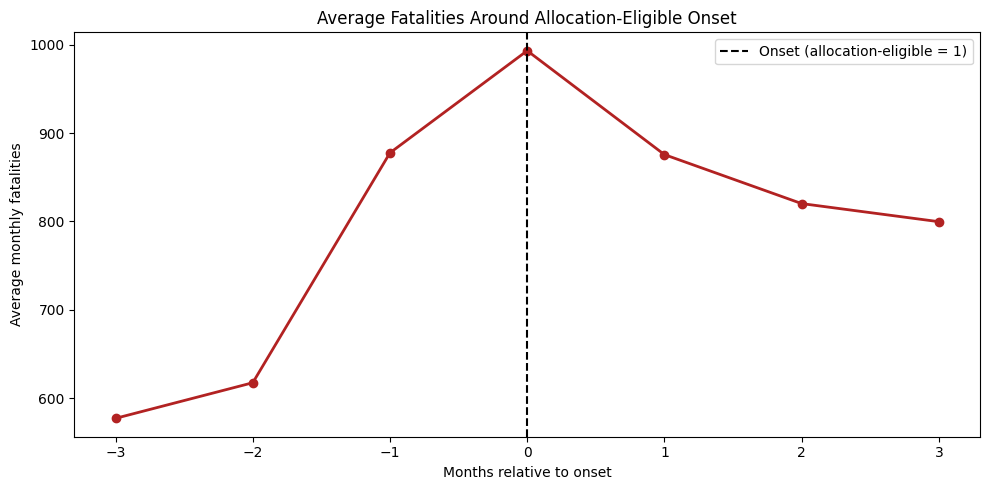

In [19]:
# Window around allocation-eligible onset
df['month'] = pd.to_datetime(df['month'])
df = df.sort_values(['iso3', 'month'])

# Find months where allocation-eligible turns 1 (onset)
df['prev_eligible'] = df.groupby('iso3')['allocation-eligible'].shift(1)
onset = df[(df['allocation-eligible'] == 1) & (df['prev_eligible'] == 0)][['iso3', 'month']].copy()

# Build window of -3 to +3 months around each onset
windows = []
for _, row in onset.iterrows():
    country = row['iso3']
    onset_month = row['month']
    for t in range(-3, 4):
        target_month = onset_month + pd.DateOffset(months=t)
        match = df[(df['iso3'] == country) & (df['month'] == target_month)]
        if not match.empty:
            windows.append({'iso3': country, 'months_to_onset': t, 
                          'fatalities': match['fatalities'].values[0]})

window_df = pd.DataFrame(windows)

# Average fatalities by months_to_onset
avg_window = window_df.groupby('months_to_onset')['fatalities'].mean().round(2)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(avg_window.index, avg_window.values, color='firebrick', linewidth=2, marker='o')
ax.axvline(x=0, color='black', linestyle='--', label='Onset (allocation-eligible = 1)')
ax.set_title('Average Fatalities Around Allocation-Eligible Onset')
ax.set_xlabel('Months relative to onset')
ax.set_ylabel('Average monthly fatalities')
ax.legend()
plt.tight_layout()
plt.show()

To assess whether conflict fatalities anticipate humanitarian crises, we constructed a event window around each allocation-eligible onset. An onset is defined as the first month in which a country transitions from non-eligible to eligible status. For each onset observed in the dataset, we extracted fatality values from 3 months before to 3 months after, then averaged across all onsets globally.

The chart reveals a clear upward trend in the months preceding the onset. Average monthly fatalities rise from approximately 580 deaths at t-3 to nearly 1,000 at t=0, the onset month itself. After the onset, fatalities gradually decline but remain elevated, suggesting that conflict intensity persists even after the crisis is officially recognized. This pattern confirms that fatalities carry predictive signal ahead of the onset of allocation-eligible periods, supporting the inclusion of ACLED fatality data as a predictor in the early warning model.

In [20]:
# Check number of onsets and where they occur
print(f"Total onsets detected: {len(onset)}")
print(f"\nOnsets by year:")
print(onset['month'].dt.year.value_counts().sort_index())
print(f"\nOnsets by country:")
print(onset['iso3'].value_counts().head(20))

Total onsets detected: 98

Onsets by year:
month
2018     7
2019     7
2020     6
2021     8
2022    11
2023    16
2024    19
2025    20
2026     4
Name: count, dtype: int64

Onsets by country:
iso3
ETH    8
SYR    8
AFG    6
CAF    6
SOM    6
NGA    5
PHL    5
SDN    5
MLI    4
PSE    4
SSD    4
BFA    3
HTI    3
LBN    3
MOZ    3
NER    3
CMR    2
IRN    2
KHM    2
MMR    2
Name: count, dtype: int64


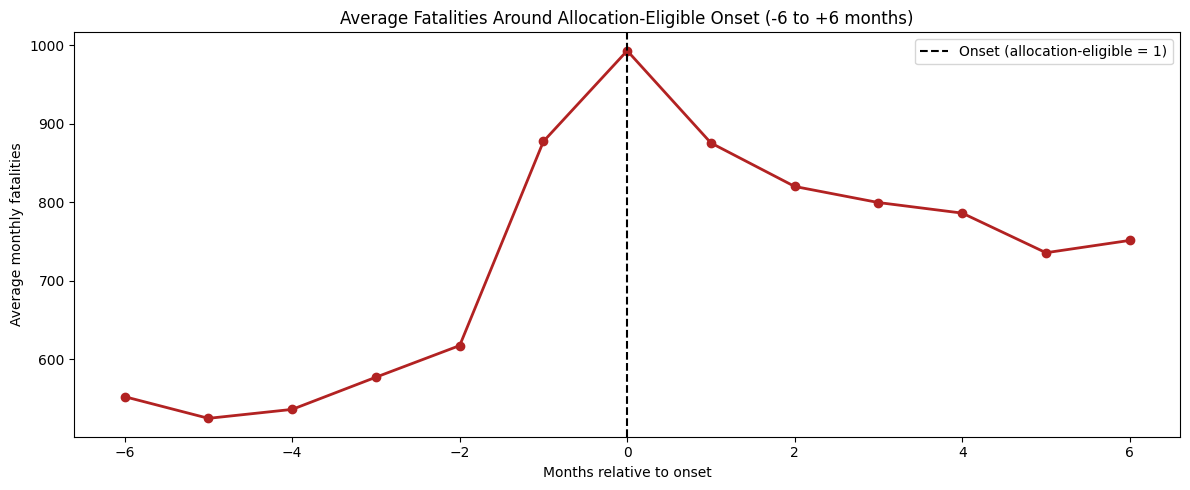

In [23]:
# Build window of -6 to +6 months around each onset
windows = []
for _, row in onset.iterrows():
    country = row['iso3']
    onset_month = row['month']
    for t in range(-6, 7):
        target_month = onset_month + pd.DateOffset(months=t)
        match = df[(df['iso3'] == country) & (df['month'] == target_month)]
        if not match.empty:
            windows.append({'iso3': country, 'months_to_onset': t, 
                          'fatalities': match['fatalities'].values[0]})

window_df = pd.DataFrame(windows)

# Average fatalities by months_to_onset
avg_window = window_df.groupby('months_to_onset')['fatalities'].mean().round(2)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(avg_window.index, avg_window.values, color='firebrick', linewidth=2, marker='o')
ax.axvline(x=0, color='black', linestyle='--', label='Onset (allocation-eligible = 1)')
ax.set_title('Average Fatalities Around Allocation-Eligible Onset (-6 to +6 months)')
ax.set_xlabel('Months relative to onset')
ax.set_ylabel('Average monthly fatalities')
ax.legend()
plt.tight_layout()
plt.show()

Expanding the window to 6 months before and after the onset reveals that fatalities remain relatively stable between t-6 and t-3, moving around 530-580 deaths per month. The sharpest increase occurs between t-2 and t=0, where the average jumps from approximately 620 to nearly 1,000 fatalities, suggesting that the predictive signal in fatalities is concentrated in the 2-3 months immediately preceding the onset rather than further in advance.

This has two important implications for the model. First, short lags (1-2 months) are likely to be more informative than longer ones. Second, fatalities behave as a late warning signal, useful for detection but with limited anticipation capacity. This is consistent with the 2-month prediction horizon of the target variable `target_2m`.

